<a href="https://colab.research.google.com/github/maryo0oma51/Foundation-of-Data-Science-Spring-2025-2026/blob/main/Group_2_AirQuality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Group** **Number**: **2**

Group Names:

1.	Rouda Al Marzooqi - U25100404
2.	Maryam Ayoub Ahli - U25102742
3.	Latifa Abdulla Alkhaja - U25103309
4.	Nour Jamal - U25104814
5.	Hamad Alobeidli - U2510568
6.	Abdulla Alnaqbi - U24200508



**In-Class Team-Based Learning Activity** : Analyzing California Air Quality Data **[15 MARKS]**
- Objective:
    - In this activity, YOU will work in teams to analyze the California Air Quality 2020 dataset. Download it from the following link:
    [California Air Quality Data](https://www.kaggle.com/datasets/thaddeussegura/california-air-quality-2020-through-sept10th)

    -  columns:
      - `Date`: The date of the measurement.
      - `Daily Mean PM2.5 Concentration`: Average PM2.5 concentration for the day.
      - `AQI`: Air Quality Index derived from PM2.5 levels.
      - `CBSA Name`: Core-Based Statistical Area (e.g., Fresno, Riverside).
      - `County Name`: County where the measurement was taken.
      - Other metadata like `latitude`, `longitude`, and units.
    
    - You will:
      - Explore the dataset to understand its structure.
      - Perform operations such as sorting, filtering, and selecting rows to extract meaningful insights.
      - Collaborate to answer questions about air quality trends and their implications.

In [ ]:
!pip install datascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.1 MB/s eta 0:00:00


In [ ]:
from datascience import *
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving California_airquality.csv to California_airquality.csv


**Step-by-Step Instructions**
- **Step 1**: Introduction to the Dataset
    - Goal : Familiarize yourself with the dataset and its columns.
      - **Task 1.1**: Load the dataset into a `table` and display the first few rows.

In [ ]:
air = Table.read_table("California_airquality.csv")
air.show(5)

Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,UNITS,DAILY_AQI_VALUE,Site Name,DAILY_OBS_COUNT,PERCENT_COMPLETE,AQS_PARAMETER_CODE,AQS_PARAMETER_DESC,CBSA_CODE,CBSA_NAME,STATE_CODE,STATE,COUNTY_CODE,COUNTY,SITE_LATITUDE,SITE_LONGITUDE
1/1/20,AQS,60010007,3,8.6,ug/m3 LC,36,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
1/2/20,AQS,60010007,3,4.5,ug/m3 LC,19,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
1/3/20,AQS,60010007,3,14.2,ug/m3 LC,55,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
1/4/20,AQS,60010007,3,10.9,ug/m3 LC,45,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
1/5/20,AQS,60010007,3,7.8,ug/m3 LC,33,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784


**Step 2**: Sorting Rows
  - Goal : Teach students how to sort rows based on specific criteria.
    - **Task 2.1** : Sort the dataset by Daily Mean PM2.5 Concentration in descending order to find the days with the worst air quality.

In [ ]:
worst_air = air.sort("Daily Mean PM2.5 Concentration", descending=True)
worst_air.select("Date", "CBSA_NAME", "COUNTY", "Daily Mean PM2.5 Concentration", "DAILY_AQI_VALUE").show(10)

Date,CBSA_NAME,COUNTY,Daily Mean PM2.5 Concentration,DAILY_AQI_VALUE
8/21/20,"Santa Cruz-Watsonville, CA",Santa Cruz,378.5,419
8/20/20,"San Luis Obispo-Paso Robles-Arroyo Grande, CA",San Luis Obispo,304.1,354
8/29/20,nan,Plumas,276.8,327
9/10/20,nan,Mariposa,263.3,314
8/25/20,nan,Plumas,251.5,302
8/20/20,"Santa Cruz-Watsonville, CA",Santa Cruz,243.9,294
8/21/20,"San Luis Obispo-Paso Robles-Arroyo Grande, CA",San Luis Obispo,236.2,286
8/24/20,nan,Plumas,232.5,282
8/26/20,nan,Plumas,231.7,281
8/30/20,nan,Plumas,222,272


**Teams should discuss why certain days might have had poor air quality (e.g., wildfires)!**


- **Task 2.2** : Sort the dataset alphabetically by `CBSA_NAME` to group data by region.

In [ ]:
by_region = air.sort("CBSA_NAME")
by_region.select("Date", "CBSA_NAME", "COUNTY", "Daily Mean PM2.5 Concentration").show(10)

Date,CBSA_NAME,COUNTY,Daily Mean PM2.5 Concentration
1/1/20,"Bakersfield, CA",Kern,36.8
1/4/20,"Bakersfield, CA",Kern,23.7
1/10/20,"Bakersfield, CA",Kern,18.5
1/13/20,"Bakersfield, CA",Kern,15.1
1/16/20,"Bakersfield, CA",Kern,21
1/19/20,"Bakersfield, CA",Kern,23.9
1/22/20,"Bakersfield, CA",Kern,11.9
1/25/20,"Bakersfield, CA",Kern,20.6
1/28/20,"Bakersfield, CA",Kern,20.1
1/31/20,"Bakersfield, CA",Kern,22.4


**Step 3**: Selecting Rows
  - Goal : Practice filtering rows based on specific conditions.
      - **Task 3.1** : Extract rows where the Daily Mean PM2.5 Concentration exceeds 50 µg/m³.

In [ ]:
high_pm = air.where("Daily Mean PM2.5 Concentration", are.above(50))
high_pm.show(10)
print("Number of rows with PM2.5 > 50:", high_pm.num_rows)

Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,UNITS,DAILY_AQI_VALUE,Site Name,DAILY_OBS_COUNT,PERCENT_COMPLETE,AQS_PARAMETER_CODE,AQS_PARAMETER_DESC,CBSA_CODE,CBSA_NAME,STATE_CODE,STATE,COUNTY_CODE,COUNTY,SITE_LATITUDE,SITE_LONGITUDE
8/20/20,AirNow,60010007,3,63.4,ug/m3 LC,155,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
8/21/20,AirNow,60010007,3,54.5,ug/m3 LC,148,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
8/23/20,AirNow,60010007,3,99.9,ug/m3 LC,174,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
8/24/20,AirNow,60010007,3,57.9,ug/m3 LC,152,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
9/10/20,AirNow,60010007,3,53.8,ug/m3 LC,146,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784
9/10/20,AirNow,60010009,3,110.5,ug/m3 LC,179,Oakland,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.7431,-122.17
9/10/20,AirNow,60010011,3,116.9,ug/m3 LC,183,Oakland West,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.8148,-122.282
9/10/20,AirNow,60010012,3,114.6,ug/m3 LC,182,Laney College,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.7936,-122.263
9/10/20,AirNow,60010013,3,122.1,ug/m3 LC,185,Berkeley Aquatic Park,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.8648,-122.303
8/19/20,AirNow,60010015,3,76.7,ug/m3 LC,162,Pleasanton - Owens Ct,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.7012,-121.903


Number of rows with PM2.5 > 50: 354


**Teams should count how many such days occurred and discuss the health implications.**

- **Task 3.2** : Find all rows corresponding to `Fresno, CA`.

In [ ]:
fresno = air.where("CBSA_NAME", "Fresno, CA")
fresno.show(10)

Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,UNITS,DAILY_AQI_VALUE,Site Name,DAILY_OBS_COUNT,PERCENT_COMPLETE,AQS_PARAMETER_CODE,AQS_PARAMETER_DESC,CBSA_CODE,CBSA_NAME,STATE_CODE,STATE,COUNTY_CODE,COUNTY,SITE_LATITUDE,SITE_LONGITUDE
1/1/20,AQS,60190011,1,42.3,ug/m3 LC,118,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/2/20,AQS,60190011,1,35.9,ug/m3 LC,102,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/3/20,AQS,60190011,1,29.6,ug/m3 LC,88,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/4/20,AQS,60190011,1,9.4,ug/m3 LC,39,Fresno - Garland,1,100,88502,Acceptable PM2.5 AQI & Speciation Mass,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/5/20,AQS,60190011,1,13.8,ug/m3 LC,55,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/6/20,AQS,60190011,1,23.7,ug/m3 LC,75,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/7/20,AQS,60190011,1,23.3,ug/m3 LC,75,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/8/20,AQS,60190011,1,18.8,ug/m3 LC,65,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/9/20,AQS,60190011,1,13.2,ug/m3 LC,53,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773
1/10/20,AQS,60190011,1,17,ug/m3 LC,61,Fresno - Garland,1,100,88101,PM2.5 - Local Conditions,23420,"Fresno, CA",6,California,19,Fresno,36.7854,-119.773


**Teams should calculate the average PM2.5 concentration for Fresno during this period.**

In [ ]:
print("Average PM2.5 in Fresno:", np.mean(fresno.column("Daily Mean PM2.5 Concentration")))

Average PM2.5 in Fresno: 11.5978438228


**Step 4**: Creating New Columns
- Goal : Teach students how to compute new metrics and add them to the table
    - **Task 4.1** : Add a column indicating whether the air quality is `"Good" (PM2.5 < 12)`, `"Moderate" (12 ≤ PM2.5 < 35)`, or `"Unhealthy" (PM2.5 ≥ 35)`.

In [ ]:
def category(pm):
    if pm < 12:
        return "Good"
    elif pm < 35:
        return "Moderate"
    else:
        return "Unhealthy"

air = air.with_column(
    "Air Quality Category",
    air.apply(category, "Daily Mean PM2.5 Concentration")
)

air.show(5)

Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,UNITS,DAILY_AQI_VALUE,Site Name,DAILY_OBS_COUNT,PERCENT_COMPLETE,AQS_PARAMETER_CODE,AQS_PARAMETER_DESC,CBSA_CODE,CBSA_NAME,STATE_CODE,STATE,COUNTY_CODE,COUNTY,SITE_LATITUDE,SITE_LONGITUDE,Air Quality Category
1/1/20,AQS,60010007,3,8.6,ug/m3 LC,36,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784,Good
1/2/20,AQS,60010007,3,4.5,ug/m3 LC,19,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784,Good
1/3/20,AQS,60010007,3,14.2,ug/m3 LC,55,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784,Moderate
1/4/20,AQS,60010007,3,10.9,ug/m3 LC,45,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784,Good
1/5/20,AQS,60010007,3,7.8,ug/m3 LC,33,Livermore,1,100,88101,PM2.5 - Local Conditions,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.6875,-121.784,Good


**Task 4.2** : Calculate the percentage of days in each category for Fresno.


In [ ]:
fresno = air.where("CBSA_NAME", "Fresno, CA")
fresno_counts = fresno.group("Air Quality Category")

total_fresno = fresno.num_rows

fresno_percent = fresno_counts.with_column(
    "Percentage",
    fresno_counts.column("count") / total_fresno * 100
)

fresno_percent.show()

Air Quality Category,count,Percentage
Good,1259,73.3683
Moderate,382,22.2611
Unhealthy,75,4.37063


**Step 5**: Group Challenge
- Goal :  solve a complex problem.
    - **Challenge** : Identify the top 3 regions (CBSA Names) with the highest average PM2.5 concentrations

In [ ]:
region_avg = air.select("CBSA_NAME", "Daily Mean PM2.5 Concentration").group(
    "CBSA_NAME",
    np.mean
).sort("Daily Mean PM2.5 Concentration mean", descending=True)

region_avg.show(10)

CBSA_NAME,Daily Mean PM2.5 Concentration mean
"Hanford-Corcoran, CA",18.794
"Visalia-Porterville, CA",14.5251
"Madera, CA",12.5733
"Merced, CA",11.8249
"Yuba City, CA",11.6283
"Fresno, CA",11.5978
"Modesto, CA",11.3933
"Los Angeles-Long Beach-Anaheim, CA",11.1954
"Stockton-Lodi, CA",10.4324
"Bakersfield, CA",10.0654


**Grading Distribution (Out of 15)**
- Below is the grading rubric for the tasks in the activity.
    - Each task will be graded based on correctness, completeness, and clarity of the solution.

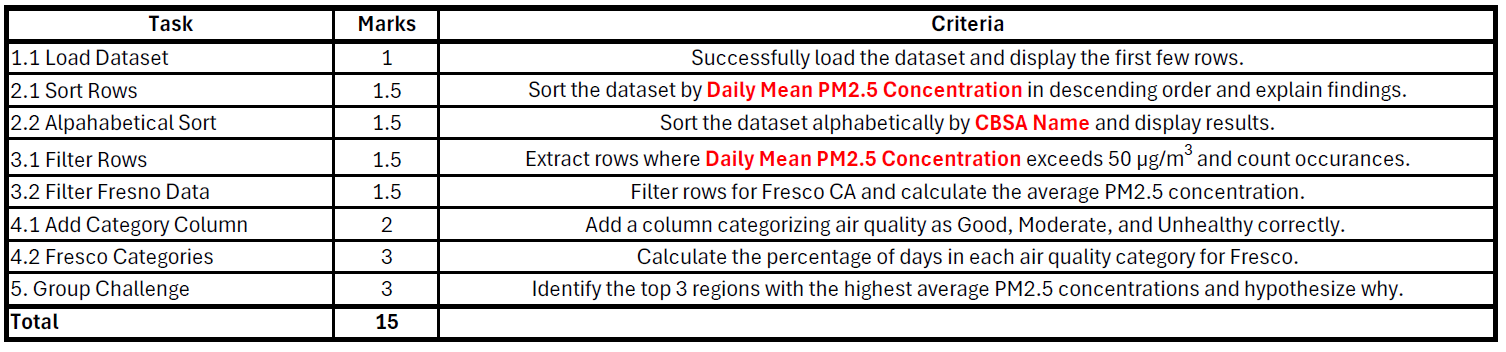